<a href="https://colab.research.google.com/github/sbsonusunil/twitter_project/blob/main/gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#gradiet descent is the change is the function or rise and run in the fuction to the change in the parameter.
#But in deep learning, “gradient” usually means the value of a function’s derivative at a particular argument value


In [2]:
from ipywidgets import interact
from fastai.basics import *
import torch.nn.functional as F
import torch

In [3]:
plt.rc('figure', dpi=90)

def plot_function(f, title=None, min=-2.1, max=2.1, color='r', ylim=None):
    x = torch.linspace(min,max, 100)[:,None]
    if ylim: plt.ylim(ylim)
    plt.plot(x, f(x), color)
    if title is not None: plt.title(title)

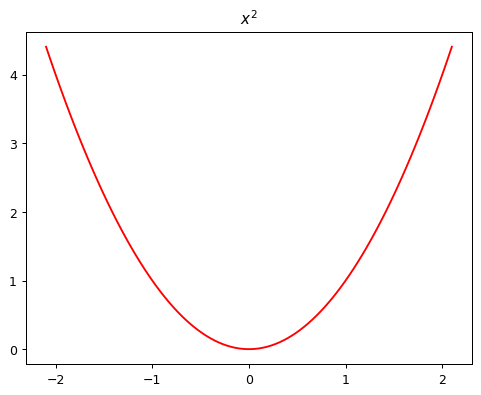

In [4]:
def f(x): return x**2

plot_function(f, "$x^2$")

In [8]:
xt=tensor(3., requires_grad=True) # calculated the derivative which is required for backpropagation and automatically calculate the gradient.
xt

tensor(3., requires_grad=True)

In [18]:
# now we can call pytorch to calculate the gradient
#The gradients tell us only the slope of our function
#they don’t tell us exactly how far to adjust the parameters
#Without SGD (or another optimizer), parameters would never change and the model would never learn.
yt = f(xt)
yt.backward()

xt.grad

tensor(12.)

SGD-a fundamental optimization algorithm in deep learning used to train models by updating parameters iteratively based on small batches (or single samples) of data rather than the whole dataset

In [19]:
time=torch.arange(0,20).float()#created a 1d tensor of every second for 20 sec.
time

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19.])

In [24]:
speed=torch.randn(20)*3+0.75*(time-9.5)**2+1 # added some noise the purpose to learn the realistic pattern

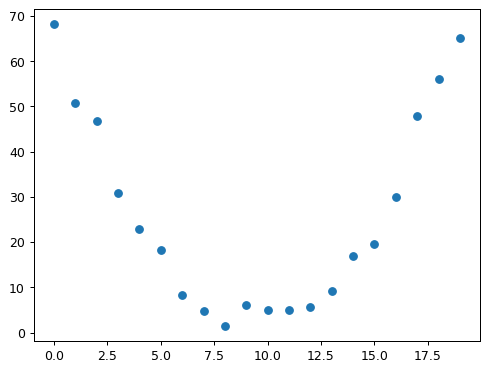

In [25]:
plt.scatter(time,speed)

In [26]:
# for general form
def f(t,params):
    a,b,c=params
    return a*(t**2)+b*t+c #we’ve restricted the problem of finding the best imaginable function that fits the data to finding the best quadratic function.

In [27]:
# we will calculate the loss by mse
def mse(pred,targets):
    return ((pred-targets)**2).mean()



In [28]:
# initilize the parameter
params=torch.randn(3).requires_grad_()

In [39]:
params

tensor([-0.0906,  0.2805, -0.8588], requires_grad=True)

In [30]:
# calculate the predictions
preds=f(time,params)

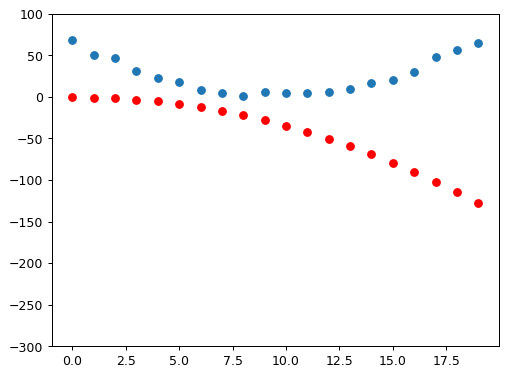

In [31]:
def show_preds(preds, ax=None):# show the results
 if ax is None: ax=plt.subplots()[1]
 ax.scatter(time, speed)
 ax.scatter(time, to_np(preds), color='red')
 ax.set_ylim(-300,100)
show_preds(preds)


In [32]:
# calculate the loss
loss=mse(preds,speed)
loss

tensor(7364.5186, grad_fn=<MeanBackward0>)

In [47]:
params.grad.zero_()

tensor([0., 0., 0.])

In [48]:
# Re-calculate predictions and loss to refresh the graph before backward
# positive parameters means increasing loss and decreasing parameter means decreasing loss.
preds = f(time, params)
loss = mse(preds, speed)
loss.backward()
params.grad

tensor([-11975.6426,   -767.0951,    -70.6412])

In [49]:
lr=1e-5
params.data -= lr * params.grad.data
params.grad = None

In [50]:
preds=f(time,params)
mse(preds,speed)

tensor(870.8651, grad_fn=<MeanBackward0>)

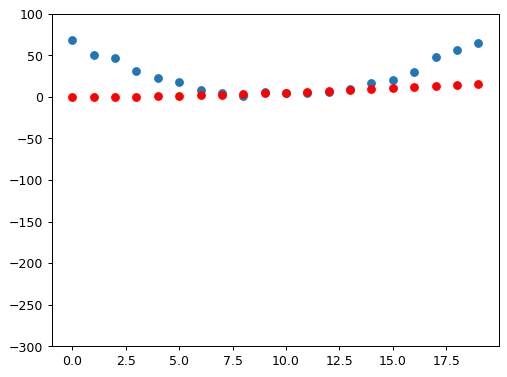

In [51]:
show_preds(preds)

In [52]:
# we need to repeat it few times to get the minimum loss
def apply_step(params, prn=True):
 preds = f(time, params)
 loss = mse(preds, speed)
 loss.backward()# calculating gradient
 params.data -= lr * params.grad.data # updating parameters
 params.grad = None
 if prn: print(loss.item())
 return preds

In [53]:
# iterate it few times
for i in range(10):
    apply_step(params)

870.8650512695312
675.3353271484375
638.3325805664062
631.3278198242188
629.9996948242188
629.7456665039062
629.6950073242188
629.6827392578125
629.6776733398438
629.6741943359375


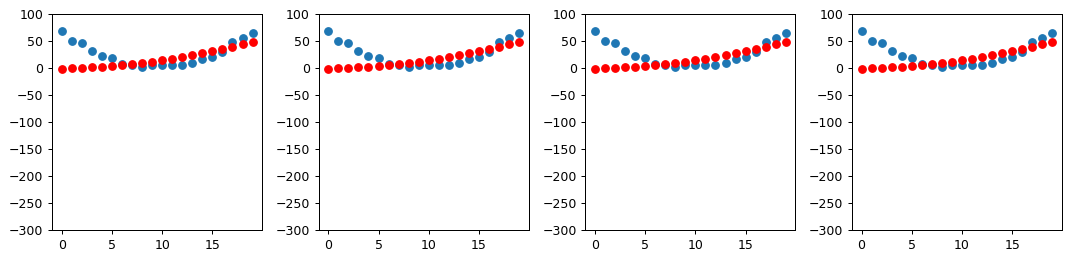

In [54]:
_,axs = plt.subplots(1,4,figsize=(12,3))
for ax in axs:
    # Run several steps to make the change visible in the plot
    for _ in range(5): preds = apply_step(params, False)
    show_preds(preds, ax)
plt.tight_layout()

Final Loss after 500 steps: 627.9776611328125


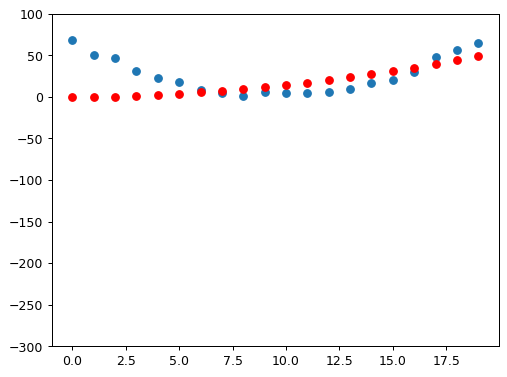

In [55]:
# Run 500 iterations
for i in range(500):
    preds = apply_step(params, prn=False)

print(f'Final Loss after 500 steps: {mse(preds, speed).item()}')
show_preds(preds)